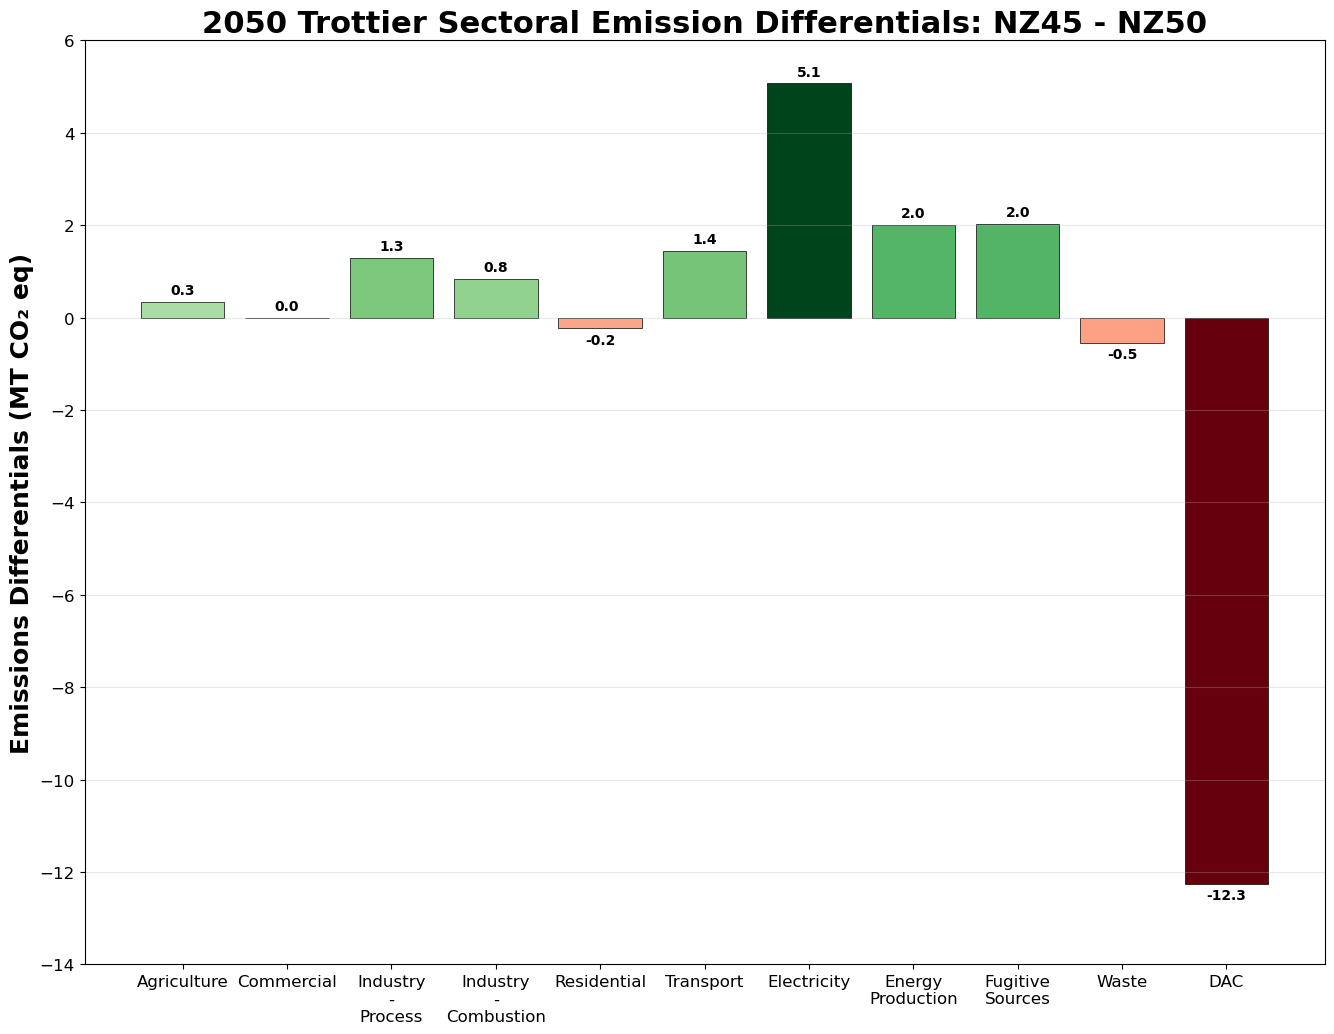

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Data extracted from Trottier's Canada Energy Outlook 2021
sectors = ["Agriculture", "Commercial", "Industry - Process", "Industry - Combustion", "Residential", "Transport", "Electricity", "Energy Production", "Fugitive Sources", "Waste", "DAC"]
emissions_differentials = [0.335267962, 0.001867276, 1.288367429, 0.847645543, -0.232093828, 1.442632619, 5.07111728, 2.009382979, 2.028847449, -0.54022224, -12.25281247]

# Create bar chart
plt.figure(figsize=(16, 12))
# 1. Normalize the values for color mapping (scales them between 0 and 1)
pos_vals = [v for v in emissions_differentials if v > 0]
neg_vals = [abs(v) for v in emissions_differentials if v < 0]

# 2. Map colors: Use plt.cm.Greens for positive and plt.cm.Reds for negative
bar_colors = []
for val in emissions_differentials:
    if val >= 0:
        # Scale intensity: max positive value gets darkest green
        intensity = 0.3 + (val / max(pos_vals)) * 0.7 
        bar_colors.append(plt.cm.Greens(intensity))
    else:
        # Scale intensity: max negative magnitude gets darkest red
        intensity = 0.3 + (abs(val) / max(neg_vals)) * 0.7
        bar_colors.append(plt.cm.Reds(intensity))

# 3. Create the bar chart with the dynamic colors
bars = plt.bar(sectors, emissions_differentials, color=bar_colors, edgecolor='black', linewidth=0.5)


# Labels
plt.ylabel("Emissions Differentials (MT CO₂ eq)", fontweight='bold', fontsize=18)

# Rotate and wrap x-axis labels for better readability
wrapped_labels = [label.replace(' ', '\n') for label in sectors]
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], labels=wrapped_labels, fontsize=12)
plt.yticks(np.arange(-14, 6 + 1, 2), fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.title("2050 Trottier Sectoral Emission Differentials: NZ45 - NZ50", fontsize=22, fontweight='bold')

# Add data labels above or below each bar
for bar in bars:
    height = bar.get_height()
    if height >= 0:
        y_pos = height + 0.1
        va = 'bottom'
    else:
        y_pos = height - 0.1
        va = 'top'
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f'{height:.1f}',
        ha='center',
        va=va,
        fontsize=10,
        fontweight='bold'
    )

# Display plot
plt.show()

